In [1]:
"""
Rayleigh–Schrödinger Eigenvector Perturbation Series
for Noisy Null-Space Recovery.

Given:
  HZ  (m x t): deterministic matrix Z
  HE  (m x t): noise matrix E = σ * ε
  Ni  (1 x m): row vector n^T (unit vector in Null(Z^T))
  sigma: noise scale such that ε = HE / sigma has O(1) entries
  K_max: number of perturbation orders to compute

Returns the corrbected eigenvector u = n + e and diagnostics.
"""

import numpy as np
from numpy.linalg import pinv, eigh, norm
import tqdm
import matplotlib.pyplot as plt



def perturbation_series(HZ, HE, Ni, sigma, K_max=6):
    """
    Compute the perturbation series solution for the smallest eigenvector
    of H(σ) = (Z + E)(Z + E)^T using Rayleigh–Schrödinger recursion.

    Parameters
    ----------
    HZ : ndarray, shape (m, t)
        Deterministic matrix Z.
    HE : ndarray, shape (m, t)
        Noise matrix E (= σ * ε).
    Ni : ndarray, shape (1, m)
        Row vector n^T, unit vector in Null(Z^T).
    sigma : float
        Noise standard deviation. Must be > 0.
    K_max : int, optional
        Maximum perturbation order (default 6).

    Returns
    -------
    result : dict with keys:
        'u'         : (m, 1) corrected unit eigenvector n + e
        'e'         : (m, 1) total correction vector
        'lambda'    : float, eigenvalue estimate
        'e_k'       : list of (m, 1) correction vectors [e_1, ..., e_K]
        'lambda_k'  : list of floats [λ_1, ..., λ_K]
        'c_k'       : list of floats [c_1, ..., c_K] (parallel components)
        'u_exact'   : (m, 1) exact smallest eigenvector (for comparison)
        'lam_exact' : float, exact smallest eigenvalue
        'errors'    : list of floats, ||e_series - e_exact|| at each order
    """
    # --- Setup ---
    Z = HZ
    E = HE
    n = Ni  # (m, 1)
    m = Z.shape[0]

    # Normalized noise matrix: ε = E / σ
    epsilon = E / sigma

    # Hamiltonian pieces (all m x m)
    H0 = Z @ Z.T
    H1 = Z @ epsilon.T + epsilon @ Z.T
    H2 = epsilon @ epsilon.T

    # Pseudoinverse of H0 (computed once)
    G = pinv(H0)


    # --- Exact solution for comparison ---
    H_full = (Z + E) @ (Z + E).T
    eigvals, eigvecs = eigh(H_full)
    u_exact = eigvecs[:, 0:1]
    if n.T @ u_exact < 0:
        u_exact = -u_exact
    e_exact = u_exact - n
    lam_exact = eigvals[0]

    # --- Recursion storage ---
    e_list = [n.copy()]  # e_list[0] = n (convention: e_0 = n)
    lam_list = [0.0]     # λ_0 = 0
    c_list = [0.0]       # c_0 not used

    def get_e(k):
        if k < 0:
            return np.zeros((m, 1))
        return e_list[k]

    # --- Main recursion ---
    errors = []

    for k in range(1, K_max + 1):
        # Step A: eigenvalue correction λ_k
        lam_k = (n.T @ H1 @ get_e(k - 1)).item() \
              + (n.T @ H2 @ get_e(k - 2)).item()
        for j in range(1, k):
            lam_k -= lam_list[j] * (n.T @ get_e(k - j)).item()
        lam_list.append(lam_k)

        # Step B: perpendicular component
        rhs = -H1 @ get_e(k - 1) - H2 @ get_e(k - 2)
        for j in range(1, k):
            rhs += lam_list[j] * get_e(k - j)
        e_perp = G @ rhs

        # Step C: parallel component
        c_k = 0.0
        for j in range(1, k):
            c_k -= 0.5 * (get_e(j).T @ get_e(k - j)).item()
        c_list.append(c_k)

        # Step D: combine
        e_k = e_perp + c_k * n
        e_list.append(e_k)

        # Track error at this truncation order
        e_series = sum(sigma**i * e_list[i] for i in range(1, k + 1))
        errors.append(norm(e_series - e_exact))
        if errors[-1]>1e5:
            K_max= k
            break
        if errors[-1]<1e-10:
            K_max= k
            break
        # print(np.linalg.norm(sigma**k*e_perp))
        # print(lam_k*sigma**k)
        # print()
    # --- Build final outputs ---
    e_total = sum(sigma**k * e_list[k] for k in range(1, K_max + 1))
    lam_total = sum(sigma**k * lam_list[k] for k in range(1, K_max + 1))
    u_total = n + e_total
    diverge= False
    if np.abs(1-np.linalg.norm(u_total))>1e-1:
        diverge= True
    return {
        'u':         u_total,
        'e':         e_total,
        'lambda':    lam_total,
        'e_k':       e_list[1:],       # [e_1, ..., e_K]
        'lambda_k':  lam_list[1:],     # [λ_1, ..., λ_K]
        'c_k':       c_list[1:],       # [c_1, ..., c_K]
        'u_exact':   u_exact,
        'lam_exact': lam_exact,
        'errors':    errors,
        'e_exact': e_exact,
        'diverge': diverge
    }


def print_report(result, sigma, K_max):
    """Pretty-print the perturbation series results."""

    print("=" * 65)
    print("  Rayleigh–Schrödinger Perturbation Series Results")
    print("=" * 65)

    lam_exact = result['lam_exact']
    e_exact = result['u_exact'] - result['u'] + result['e']  # recover

    print(f"\n  σ = {sigma},  K_max = {K_max}")
    print(f"  Exact smallest eigenvalue:  {lam_exact:.8e}")
    print(f"  Series eigenvalue estimate: {result['lambda']:.8e}")
    print(f"  ||e_total||:                {norm(result['e']):.8e}")
    print(f"  ||u_total|| (should be ~1): {norm(result['u']):.10f}")

    print(f"\n  {'Order':>5s}  {'λ_k':>13s}  {'c_k':>13s}  "
          f"{'||e_k||':>13s}  {'||error||':>13s}")
    print(f"  {'-----':>5s}  {'-------------':>13s}  {'-------------':>13s}  "
          f"{'-------------':>13s}  {'-------------':>13s}")

    for k in range(K_max):
        print(f"  {k+1:5d}  {sigma**k*result['lambda_k'][k]:+13.4e}  "
              f"{sigma**k*result['c_k'][k]:+13.4e}  "
              f"{norm(sigma**k*result['e_k'][k]):13.4e}  "
              f"{result['errors'][k]:13.4e}")

    print(f"\n  Final relative error: "
          f"{result['errors'][-1] / max(norm(result['e']), 1e-30):.4e}")
    print("=" * 65)


# ================================================================
# Example usage with synthetic data
# ================================================================
if __name__ == "__main__":
    # np.random.seed(28)

    m, t = 2, 8000
    n= m-1
    rankH= n
    nullity= m-n
    # USE LARGE SIGMA for this test
    sigma = 4
    H= np.random.randn(m, n)
    H= H/np.linalg.norm(H)
    U, S, V= np.linalg.svd(H)
    SM = np.zeros((m, n))
    setRank= rankH-1
    SM[:setRank, :setRank] = np.diag(S[0:setRank])
    HM= U@SM@V
    HL= H-HM
    HE= (np.random.randn(t, H.shape[0])*sigma).T
    HX= np.random.randn(H.shape[1], t)
    HZ= H@HX
    Ni= U[:, -1:]
    U, S, V= np.linalg.svd(HZ)
    print(S)
    print(np.linalg.norm(HE.T@U[:, -1][:, None]))
    print(np.linalg.norm(HE.T@U[:, -2][:, None]))
    print(np.linalg.norm(HE.T@U[:, -2:], axis=0).sum())
    print(np.linalg.norm(HE.T@U[:, -2:], axis=0).sum()>S[-2])
    # --- Run ---
    result = perturbation_series(HZ, HE, Ni, sigma, K_max=120)
    print_report(result, sigma, K_max=10)
    # --- Quick sanity checks ---
    print("\nSanity checks:")
    print(f"  Z^T n ≈ 0:  ||Z^T n|| = {norm(HZ.T @ Ni):.2e}")
    print(f"  ||n|| = 1:   {norm(Ni):.10f}")
    print(f"  n^T e_1 = 0: {abs((Ni.T @ result['e_k'][0]).item()):.2e}")
    print("diverge:", result["diverge"])

[8.85842404e+01 3.80405045e-14]
360.3583808744887
363.20309554633104
723.5614764208198
True
  Rayleigh–Schrödinger Perturbation Series Results

  σ = 4,  K_max = 10
  Exact smallest eigenvalue:  1.29540517e+05
  Series eigenvalue estimate: 1.29540517e+05
  ||e_total||:                1.67265419e-01
  ||u_total|| (should be ~1): 0.9999999994

  Order            λ_k            c_k        ||e_k||      ||error||
  -----  -------------  -------------  -------------  -------------
      1    -1.4921e-13    +0.0000e+00     1.3270e-02     2.2021e-01
      2    +3.2459e+04    -3.5221e-04     7.4646e-02     7.9816e-02
      3    +6.1557e+01    +3.9623e-03     6.3444e-03     6.5491e-02
      4    -1.7343e+02    -1.1407e-02     2.2986e-02     2.7009e-02
      5    +3.2364e+00    +4.2572e-04     8.8741e-03     2.1311e-02
      6    +4.8031e+01    +6.3323e-03     8.6233e-03     1.3185e-02
      7    -1.7215e+01    -3.1714e-03     3.9092e-03     1.8151e-02
      8    +4.6237e+00    +7.4754e-04     7.

In [2]:
m = 5
n= m-1
rankH= n
nullity= m-n
H= np.random.randn(m, n)
# H= H/np.linalg.norm(H)



In [3]:
def find_x_o(OE, HZ, Ni, target=1.0, low=1e-5, high=10.0, tol=1e-2):
    sigmas= []
    errors= []
    while (high - low) > tol:
        mid = (low + high) / 2
        sigma= mid
        sigmas.append(sigma)
        HE= (OE*sigma).T
        result = perturbation_series(HZ, HE, Ni, sigma, K_max=100)
        indicator= result["errors"][-1]
        errors.append(indicator)
        if indicator < target:
            low = mid
        else:
            high = mid   
    return (low + high) / 2, sigmas, errors



In [4]:
t= 100
repeat= 1
loops= 100
changePoints= []
S2s= []
SAlls= []
ts= []
ns= []
A = np.random.randn(m, n)
Q, R = np.linalg.qr(A)
H = Q
OE= np.random.randn(t, H.shape[0])
for i in tqdm.tqdm(range(repeat)):
    HX= np.random.randn(H.shape[1], t)
    ns.append(n)
    ts.append(t)
    H = Q
    HZ= H@HX
    HE= (OE*sigma).T
    U, S, V= np.linalg.svd(HZ)
    Ni= U[:, -1:]
    S2s.append(S[-2])
    U, S, V= np.linalg.svd(H)
    # S2s.append(S[-2])
    SAlls.append(np.linalg.norm(np.linalg.pinv(H)))
    errorsT= []
    changeFlag= 1
    changePoint, sigmas, errors= find_x_o(OE, HZ, Ni, target=1, low=0.0, high=4.0, tol=1e-5)
    changePoints.append(changePoint)

100%|██████████| 1/1 [00:00<00:00,  2.34it/s]


1.5345420837402344
[1.21081856e+01 1.13832140e+01 1.02696509e+01 9.13707860e+00
 3.35149324e-15]
12.951618635681218
1.4109554738323706


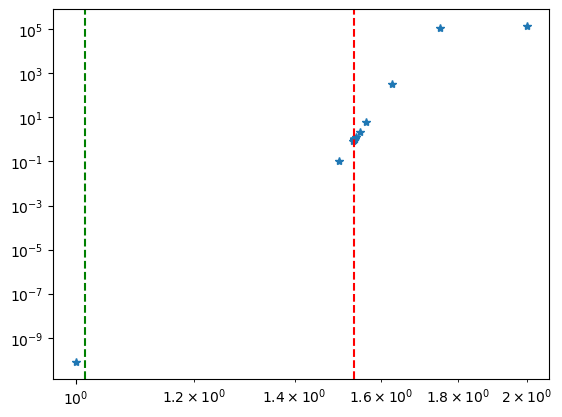

In [5]:
U, S, V= np.linalg.svd(HZ)
print(changePoint)
setSigma= changePoint
HEJ= OE.T*setSigma+HZ
calSigma= S[-2]/np.linalg.norm((OE.T).T@U[:, -1])
print(S)
distr= np.linalg.norm(((OE.T).T@U[:, -2:]))
print(distr)
print(2*S[-2]/(distr))

# U1, S1, V1= np.linalg.svd(HEJ)
# print(U1[:, -1].T@U[:, -2])
# print(U1[:, -2].T@U[:, -2])

plt.plot(sigmas, errors, "*")
plt.axvline(x=setSigma, color='red', linestyle='--')
plt.axvline(x=calSigma, color='green', linestyle='--')
plt.yscale("log")
plt.xscale("log")

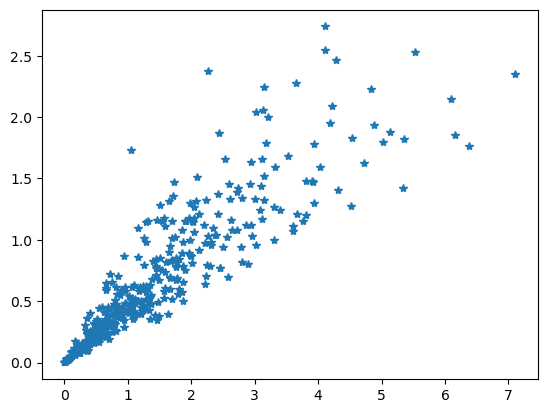

In [450]:
S2sNp= np.array(S2s)
SAllsNp= np.array(SAlls)
nsNp= np.array(ns)
tsNp= np.array(ts)
changePointsNp= np.array(changePoints)
plt.plot(S2sNp, (changePointsNp), "*")
# plt.plot((tsNp), (S2sNp), "*")
# plt.plot((ns), (SAllsNp), "*")
# plt.yscale("log")
# plt.xscale("log")

[0.43412333]
4
5
1


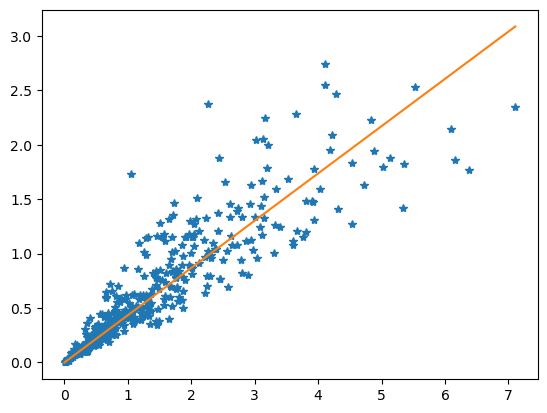

In [451]:
a, residuals, rank, s = np.linalg.lstsq(S2sNp[:, None], changePointsNp, rcond=None)
x_fit = np.linspace(0, max(S2sNp), 100)
y_fit = a * x_fit
plt.plot(S2sNp, (changePointsNp), "*")
plt.plot(x_fit, y_fit)

print(a)

print(n)
print(t)
print(nullity)

In [ ]:



paraS= [0.42604285, 0.54959855, 0.29251358, 0.74375498, 0.695571]
mS= [3, 4, 5, 10, 3]
nS= [2, 2, 4, 9, 2]
tS= [3, 5, 5, 5, 10]
lS= [1, 1, 1, 1, 1]



In [ ]:
print(np.square(0.695571/0.54959855))
print(np.sqrt(10+2)/np.sqrt(5+2))

print(np.square(0.54959855/0.42604285))
print(np.sqrt(5+2)/np.sqrt(3+2))

1.6017391004278099
1.5
1.6641198234875956
1.414213562373095


In [170]:
"""
Rayleigh–Schrödinger Eigenvector Perturbation Series
for Large Noise Regime (Expansion in 1/σ).

Given:
  HZ  (m x t): deterministic matrix Z
  HE  (m x t): noise matrix E = σ * ε
  Ni  (1 x m): row vector n^T (unit vector in Null(Z^T))
  sigma: noise scale (assumed large)
  K_max: number of perturbation orders to compute

Returns the corrected eigenvector u = n + e and diagnostics.
"""

import numpy as np
from numpy.linalg import pinv, eigh, norm

def perturbation_series_large_noise(HZ, HE, Ni, sigma, K_max=6, debug= False):
    """
    Compute the perturbation series solution for the smallest eigenvector
    of H(ε) using expansion in powers of ε = 1/σ.
    
    The Hamiltonian is scaled by 1/σ^2:
    H(ε) = (εZ + ε_noise)(εZ + ε_noise)^T
         = ε_noise @ ε_noise.T + ε(...) + ε^2(...)
    
    Parameters
    ----------
    HZ, HE, Ni, sigma : see docstring above.
    K_max : int
        Maximum perturbation order.

    Returns
    -------
    result : dict
        Contains 'u', 'e', 'lambda', 'errors', etc.
    """
    # --- Setup ---
    Z = HZ
    n = Ni  # (m, 1) reference vector
    m = Z.shape[0]
    
    # 1. Define Perturbation Parameter epsilon
    epsilon = 1.0 / sigma
    
    # 2. Normalized matrices
    # E_norm is the O(1) noise matrix: E = sigma * E_norm
    E_norm = HE / sigma 
    
    # 3. Define Hamiltonian terms for H(ε) = H0 + ε*H1 + ε^2*H2
    # Base term is now the Noise Covariance (dominant at large sigma)
    H0 = E_norm @ E_norm.T  
    
    # First interaction term
    H1 = Z @ E_norm.T + E_norm @ Z.T
    
    # Second order term (Signal Covariance)
    H2 = Z @ Z.T

    # --- Base Case (Order 0) ---
    # Solve eigenvalue problem for H0 (Noise only)
    vals, vecs = eigh(H0)
    
    # Sort just in case (eigh usually returns sorted, but be safe)
    idx = np.argsort(vals)
    mu_0 = vals[idx[0]]      # Smallest eigenvalue of noise covariance
    u_0 = vecs[:, idx[0]:idx[0]+1] # Corresponding eigenvector
    
    # Align u_0 sign with n (optional, but helps comparison)
    # Note: The global minimizer might be antiparallel to n, but we fix a convention.
    if n.T @ u_0 < 0:
        u_0 = -u_0

    # Reduced Resolvent (Pseudo-inverse of H0 - mu_0*I)
    # This projects onto the subspace orthogonal to u_0

    R0 = pinv(H0 - mu_0 * np.eye(m), rcond=1e-5)

    vals, vecs = np.linalg.eigh(H0)
    lam_0 = vals[0]
    inv_diag = np.zeros_like(vals)
    for i in range(1, len(vals)):
        inv_diag[i] = 1.0 / (vals[i] - lam_0)
    R0 = vecs @ np.diag(inv_diag) @ vecs.T

    u, s, v= np.linalg.svd(H0 - mu_0 * np.eye(m))
    if debug:
        print(R0)
        print(np.linalg.norm(R0))
    
    # --- Recursion Lists ---
    u_list = [u_0]      # u_0
    mu_list = [mu_0]    # μ_0
    c_list = [0.0]      # c_0 (not used)

    def get_u(k):
        if k < 0: return np.zeros((m, 1))
        return u_list[k]

    # --- Exact Solution for Verification ---
    # Solve full problem (Z + E)(Z + E)^T
    H_full = (Z + HE) @ (Z + HE).T
    evals_exact, evecs_exact = eigh(H_full)
    u_exact = evecs_exact[:, 0:1]
    
    # Align exact solution with our u_0 base
    if u_0.T @ u_exact < 0:
        u_exact = -u_exact
    
    e_exact = u_exact - n
    
    # --- Main Loop ---
    errors = []
    
    for k in range(1, K_max + 1):
        # -- Step A: Eigenvalue Correction μ_k --
        # Project onto u_0
        term1 = u_0.T @ H1 @ get_u(k-1)
        term2 = u_0.T @ H2 @ get_u(k-2)
        
        sum_prev = 0.0
        for j in range(1, k):
            sum_prev += mu_list[j] * (u_0.T @ get_u(k-j)).item()
            
        mu_k = (term1 + term2 - sum_prev).item()
        mu_list.append(mu_k)
        
        # -- Step B: Vector Correction u_k --
        # 1. Calculate RHS vector
        rhs = -(H1 @ get_u(k-1)) - (H2 @ get_u(k-2))
        
        # Add back μ terms (excluding current μ_k which cancels with LHS)
        for j in range(1, k):
            rhs += mu_list[j] * get_u(k-j)
            
        # 2. Orthogonal part (using Resolvent)
        u_perp = R0 @ rhs
        
        # 3. Parallel part (normalization constraint)
        c_k = 0.0
        for j in range(1, k):
            c_k -= 0.5 * (get_u(j).T @ get_u(k-j)).item()
        c_list.append(c_k)
        
        # 4. Combine
        u_k = u_perp + c_k * u_0
        u_list.append(u_k)
        
        # -- Track Error --
        # Series u = u0 + ε u1 + ε^2 u2 ...
        u_series_k = sum(epsilon**i * u_list[i] for i in range(k + 1))
        e_series_k = u_series_k - n
        errors.append(norm(e_series_k - e_exact))

    # --- Final Construction ---
    u_total = sum(epsilon**k * u_list[k] for k in range(K_max + 1))
    e_total = u_total - n
    
    # Re-scale eigenvalue back to original scale (multiply by σ^2)
    # The calculated μ is for the scaled matrix H/σ^2
    lambda_total = (sigma**2) * sum(epsilon**k * mu_list[k] for k in range(K_max + 1))

    return {
        'u': u_total,
        'e': e_total,
        'lambda': lambda_total,
        'u_list': u_list,
        'mu_list': mu_list,
        'u_exact': u_exact,
        'errors': errors,
        'epsilon': epsilon,
        'u_exact': u_exact
    }

def print_large_noise_report(result, sigma, K_max):
    print("="*65)
    print("  Large Noise Regime (Expansion in 1/σ)")
    print("="*65)
    
    eps = result['epsilon']
    u_series = result['u']
    u_exact = result['u_exact']
    
    print(f"\n  σ = {sigma:.1f}  (ε = {eps:.4f})")
    print(f"  ||u_series - u_exact||: {norm(u_series - u_exact):.4e}")
    print(f"  ||u_series||:           {norm(u_series):.8f}")
    
    print(f"\n  {'Order':>5s}  {'μ_k':>12s}  {'||u_k||':>12s}  {'Error':>12s}")
    print(f"  {'-----':>5s}  {'------------':>12s}  {'------------':>12s}  {'------------':>12s}")
    
    for k in range(K_max):
        # Note: Contribution to total vector is (1/σ)^k * u_k
        term_mag = (eps**(k+1)) * norm(result['u_list'][k+1])
        print(f"  {k+1:5d}  {result['mu_list'][k+1]:+12.4e}  "
              f"{norm(result['u_list'][k+1]):12.4e}  "
              f"{result['errors'][k]:12.4e}")
    print("="*65)

# ================================================================
# Example Usage
# ================================================================
if __name__ == "__main_":
    # np.random.seed(42)
    m, t = 2, 100
    n= m-1
    nullity= m-n
    # USE LARGE SIGMA for this test
    sigma = 2

    H= np.random.randn(m, n)
    H= H/np.linalg.norm(H)

    A = np.random.randn(m, n)
    Q, R = np.linalg.qr(A)
    H = Q  

    HE= (np.random.randn(t, H.shape[0])*sigma).T
    HX= np.random.randn(H.shape[1], t)
    HZ= H@HX
    U, S, V= np.linalg.svd(HZ.T)
    Ni= V[-2:-1, :].T

    res = perturbation_series_large_noise(HZ, HE, Ni, sigma, K_max=15, debug= True)
    u, s, v= np.linalg.svd(HZ+HE)
    print((HZ+HE).shape)
    print(s)
    print_large_noise_report(res, sigma, K_max=8)

In [465]:
numPop= 1e3
loops= 30
iterations= 400
m = 3
n= m-1
nullity= m-n
rankH= n
H= np.random.randn(m, n)
H= H/np.linalg.norm(H)
_, sH, _= np.linalg.svd(H)

In [483]:
t= 100
setRank= rankH
setNullity= m- setRank
U, S, V= np.linalg.svd(H)
SM = np.zeros((m, n))
SM[:setRank, :setRank] = np.diag(S[0:setRank])
HM= U@SM@V
HL= H-HM

# A = np.random.randn(m, n)
# Q, R = np.linalg.qr(A)
# H = Q  
expEmp= []
expGen= []
expEmpOrdered= []
expEmpCal= []
expGenCal= []
numSpales= []

randHE= []
randHX= []
randXipop= []
randpopE= []
for i in tqdm.tqdm(range(iterations)):
    randHE.append(np.random.randn(t, H.shape[0]).T)
    randHX.append(np.random.randn(H.shape[1], t))
    randXipop.append(np.random.randn(H.shape[1], int(numPop))) 
    randpopE.append(np.random.randn(int(numPop), H.shape[0]).T)

for j in tqdm.tqdm(range(loops)):
    sigma= 10*10**(-3+j/loops*3)
    eRank= rankH
    for i in range(sH.shape[0]):
        if np.sqrt(sigma)>sH[i]:
            eRank-= 1
    eNullity= m- eRank
    empOrderedSum= 0
    numSpales.append(sigma)
    empList= []
    genList= []
    for i in range(iterations):
        HX= randHX[i]
        HE= randHE[i]*sigma+HL@HX
        HZ= HM@HX
        HZE= HZ+HE
        U, S, V= np.linalg.svd(HZ.T)
        for kk in range(setNullity):
            if kk==0:
                Ni= V[-1:, :].T
            else:
                Ni= V[-kk-1:-kk, :].T
            # print(Ni.shape)
            result = perturbation_series(HZ, HE, Ni, sigma, K_max=20)
            empOrderedSum+= np.square(HZE.T@(result["e"]+Ni)).sum()/t
        Xipop= randXipop[i]
        popE= randpopE[i]*sigma+HL@Xipop
        popZ= HM@Xipop
        popZE= popZ+popE
        U, S, V= np.linalg.svd(HZE@HZE.T)
        NiE= V[-setNullity:, :].T
        empList.append(np.mean(np.square(HZE.T@NiE)))
        genList.append(np.mean(np.square(popZE.T@NiE)))
    expEmp.append(np.mean(empList))
    expGen.append(np.mean(genList))
    expEmpOrderedItem= empOrderedSum/iterations/setNullity
    if expEmpOrderedItem>100000:
        expEmpOrderedItem= np.nan
    expEmpOrdered.append(expEmpOrderedItem)
    expEmpCal.append(sigma**2-rankH/t*sigma**2)
    expGenCal.append(sigma**2+rankH/(t-n)*sigma**2)#+sigma**4*np.square(1/sH[0:eRank]).sum()/(t-n-1)/t)



100%|██████████| 30/30 [00:08<00:00,  3.49it/s]


In [481]:
expEmpCal= []
expGenCal= []
for j in tqdm.tqdm(range(loops)):
    sigma= 1*10**(-2+j/loops*2)
    eRank= rankH
    gamma= n/t
    ratio= np.square(1-np.sqrt(n/t))/(1+np.sqrt(n/t))/(1+np.sqrt(m/t))
    for i in range(sH.shape[0]):
        if sigma>np.sqrt(sH[i])/ratio:
            eRank-= 1
    eNullity= m- eRank
    # print(sigma, eRank)
    expEmpCal.append(sigma**2-eRank/t*sigma**2)
    expGenCal.append(sigma**2+eRank/(t-n)*sigma**2)
changePoints= []
for i in range(sH.shape[0]):
    ratio= np.sqrt(t)* (np.sqrt(m)-np.sqrt(n))
    ratio2= (np.sqrt(t)-np.sqrt(n))/(np.sqrt(t)+np.sqrt(n))
    changePoints.append(sH[i]*ratio2)
    pass
print(sH)

100%|██████████| 30/30 [00:00<00:00, 57430.00it/s]

[0.80637609 0.59140308]


SNR: -23.01106789535212 dB


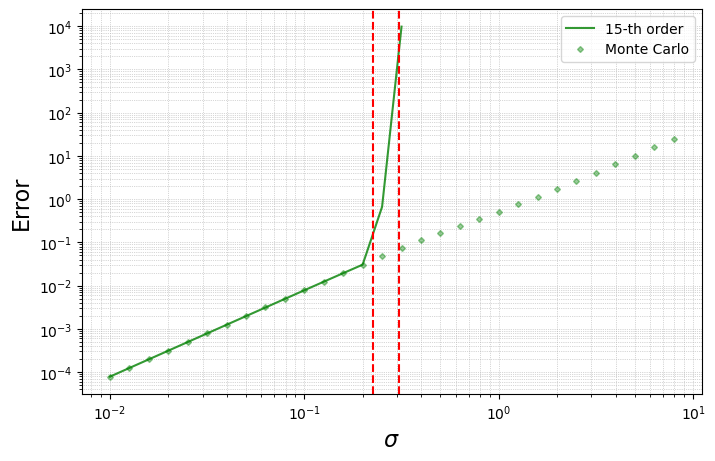

In [482]:
plt.figure(figsize=(8, 5))
print("SNR:", 10*np.log10(np.square(HZ).sum()/np.square(HE).sum()), "dB")

plt.plot(numSpales, expEmpOrdered, color= "green", alpha=0.8, label= "15-th order")

# plt.plot(numSpales, expEmpCal, label= "1-st order")
plt.plot(numSpales, expEmp, 'D', markersize=3, alpha=0.4, color="green", label= "Monte Carlo")
for point in changePoints:
    plt.axvline(x=point, color='red', linestyle='--')
# plt.plot(numSpales, expGenCal, label= "CalGen")
# plt.plot(numSpales, expGen, label= "MonteGen")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.xlabel(r'$\sigma$', fontsize=16)
plt.ylabel(r'Error', fontsize=16)
plt.grid(True, which='both', linestyle=':', linewidth=0.5)

In [146]:
u, s, v= np.linalg.svd(H)
print(min(s))
idx= 0
for i in range(len(numSpales)):
    if numSpales[i]<min(s):
        idx= i
print(numSpales[idx+1], numSpales[idx])
print(expEmpOrdered[idx+1], expEmpOrdered[idx])

0.3647213391180401
0.3981071705534973 0.25118864315095796
1000000 578318.3185971713


In [ ]:
m, t = 20, 40
n= m-1
nullity= m-n
# USE LARGE SIGMA for this test
sigma = 0.003
H= np.random.randn(20, n)
H= H/np.linalg.norm(H)
HE= (np.random.randn(t, H.shape[0])*sigma).T
HX= np.random.randn(H.shape[1], t)
HZ= H@HX
U, S, V= np.linalg.svd(HZ.T)
Ni= V[-nullity:, :]
# --- Run ---
result = perturbation_series(HZ, HE, Ni, sigma, K_max=20)

In [11]:
u, s, v= np.linalg.svd(H)
print(2*np.max(s)*(1+np.sqrt(n/t)))

1.424918935582291
